In [551]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import os
import joblib

In [552]:
df = pd.read_csv('../datasets/data_compramostucoche.csv', sep=';', encoding='utf-8')
df.head()

,marca_nombre,marca_id,version_id_catalogo,titulo_anuncio,registro,km,cambio,combustible,cv,precio
0,Kia,425,3457.0,Kia cee'd 1.6 CRDi,06/2014,17222,Manual,Diésel,128,12599
1,Kia,425,3554.0,Kia Sorento 1.6 TGDI Plug-in Hybrid,04/2024,32462,Automático,Híbrido,265,40999
2,Peugeot,670,6159.0,Peugeot 3008 2.0 Blue-HDi,07/2018,78068,Manual,Diésel,150,17299
3,Mercedes-Benz,570,NaN,Mercedes-Benz Clase GLA GLA 250e,02/2024,19060,Automático,Híbrido,218,39999
4,Citroen,190,1551.0,Citroen C4 Cactus 1.6 Blue-HDi,10/2016,94982,Manual,Diésel,100,9399


In [553]:
df = df.rename(columns={
    'marca_nombre': 'make',
    'km': 'kms',
})

In [554]:
df.isnull().sum()

make                     0
marca_id                 0
version_id_catalogo    418
titulo_anuncio           0
registro                 0
kms                      0
cambio                   0
combustible              0
cv                       0
precio                   0
dtype: int64

In [555]:
data_null = df[df['version_id_catalogo'].isnull()]

data_null['make'].value_counts()

make
Mercedes-Benz     179
BMW                93
Seat               53
Citroen            50
Ford                9
Audi                7
Mazda               5
Cupra               3
Renault             2
Land Rover          2
Peugeot             2
Suzuki              1
Toyota              1
DS Automobiles      1
Volkswagen          1
Hyundai             1
MG                  1
Ssangyong           1
Fiat                1
Opel                1
Kia                 1
Jeep                1
Nissan              1
Mitsubishi          1
Name: count, dtype: int64

In [556]:
df_modelos = pd.read_csv('../datasets/seed_modelos.csv', sep=';', encoding='utf-8')
df_versiones = pd.read_csv('../datasets/seed_versiones.csv', sep=';', encoding='utf-8')
df_marcas = pd.read_csv('../datasets/seed_marcas.csv', sep=';', encoding='utf-8')

In [557]:
df_catalogo_completo = df_versiones.merge(df_modelos, on='modelo_id')
df_catalogo_completo = df_catalogo_completo.merge(df_marcas, on='marca_id')
df_catalogo_completo

,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth
...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr


In [558]:
df_catalogo_completo.rename(columns={
    'version_id': 'version_id_catalogo'
})

,version_id_catalogo,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth
...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr


In [559]:
df_catalogo_completo['titulo_anuncio'] = df_catalogo_completo['nombre_marca'] + ' ' + df_catalogo_completo['nombre_modelo'] + ' ' + df_catalogo_completo['clave_motor']

In [560]:
df_catalogo_completo['titulo_anuncio'] = df_catalogo_completo['titulo_anuncio'].str.lower()
df['titulo_anuncio'] = df['titulo_anuncio'].str.lower()

In [561]:
df_catalogo_completo

,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca,titulo_anuncio
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth,abarth 124 spider 1.4 turbo
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth,abarth 124 spider gt
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth,abarth 500 1.4 turbo
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth,abarth 500e electric drive 114 kw
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth,abarth 500e cabrio electric drive 114 kw
...,...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr,zeekr 7x single motor 310 kw
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr,zeekr 001 electric drive 200 kw
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr,zeekr 001 electric drive 400 kw
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr,zeekr x electric drive 200 kw


In [562]:
df['version_id_catalogo'] = df['version_id_catalogo'].astype('Int64')

In [563]:
df_final = df.merge(df_catalogo_completo, how='left', on='titulo_anuncio')
df_final

,make,marca_id_x,version_id_catalogo,titulo_anuncio,registro,kms,cambio,combustible,cv,precio,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id_y,nombre_marca
0,Kia,425,3457,kia cee'd 1.6 crdi,06/2014,17222,Manual,Diésel,128,12599,3458.0,694.0,1.6 CRDi,cee'd 1.6 CRDi,cee'd,cee'd,425.0,Kia
1,Kia,425,3554,kia sorento 1.6 tgdi plug-in hybrid,04/2024,32462,Automático,Híbrido,265,40999,3554.0,723.0,1.6 TGDI Plug-in Hybrid,Sorento 1.6 TGDI Plug-in Hybrid,Sorento,Sorento,425.0,Kia
2,Peugeot,670,6159,peugeot 3008 2.0 blue-hdi,07/2018,78068,Manual,Diésel,150,17299,6159.0,1127.0,2.0 Blue-HDi,3008 2.0 Blue-HDi,3008,3008,670.0,Peugeot
3,Mercedes-Benz,570,<NA>,mercedes-benz clase gla gla 250e,02/2024,19060,Automático,Híbrido,218,39999,4645.0,898.0,GLA 250e,GLA-Klasse GLA 250e,GLA-Klasse,Clase GLA,570.0,Mercedes-Benz
4,Citroen,190,1551,citroen c4 cactus 1.6 blue-hdi,10/2016,94982,Manual,Diésel,100,9399,1551.0,277.0,1.6 Blue-HDi,C4 Cactus 1.6 Blue-HDi,C4 Cactus,C4 Cactus,190.0,Citroen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3109,Peugeot,670,6017,peugeot 308 1.6 e-hdi,10/2013,104553,Manual,Diésel,115,8999,6019.0,1111.0,1.6 e-HDi,308 1.6 e-HDi,308,308,670.0,Peugeot
3110,Seat,790,6861,seat exeo 2.0 tdi,08/2012,153084,Manual,Diésel,120,7499,6861.0,1231.0,2.0 TDI,Exeo 2.0 TDI,Exeo,Exeo,790.0,Seat
3111,Peugeot,670,6135,peugeot 2008 1.2 puretech,09/2018,57320,Manual,Gasolina,130,12699,6138.0,1126.0,1.2 PureTech,2008 1.2 PureTech,2008,2008,670.0,Peugeot
3112,MINI,580,5136,mini cabrio one,03/2018,55773,Manual,Gasolina,102,17999,5136.0,953.0,One,Cabrio One,Cabrio,Cabrio,580.0,MINI


In [564]:
df_final.isnull().sum()

make                     0
marca_id_x               0
version_id_catalogo    418
titulo_anuncio           0
registro                 0
kms                      0
cambio                   0
combustible              0
cv                       0
precio                   0
version_id              88
modelo_id               88
clave_motor             88
nombre_completo         88
id_web                  88
nombre_modelo           88
marca_id_y              88
nombre_marca            88
dtype: int64

In [565]:
df_final.drop(columns=['marca_id_x', 'version_id_catalogo', 'titulo_anuncio', 'version_id', 'modelo_id', 'nombre_marca', 'marca_id_y', 'id_web', 'nombre_completo'], inplace=True)

In [566]:
df_final = df_final.rename(columns={
    'clave_motor': 'version',
    'nombre_modelo': 'model',
    'cambio': 'gear_type',
    'precio': 'price',
    'combustible': 'fuel_type',
    'cv': 'power',
    'registro': 'registration'
})

In [567]:
df_final = df_final.dropna()

In [568]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 3026 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   make          3026 non-null   str  
 1   registration  3026 non-null   str  
 2   kms           3026 non-null   int64
 3   gear_type     3026 non-null   str  
 4   fuel_type     3026 non-null   str  
 5   power         3026 non-null   int64
 6   price         3026 non-null   int64
 7   version       3026 non-null   str  
 8   model         3026 non-null   str  
dtypes: int64(3), str(6)
memory usage: 236.4 KB


In [569]:
df_final.isnull().sum()

make            0
registration    0
kms             0
gear_type       0
fuel_type       0
power           0
price           0
version         0
model           0
dtype: int64

In [570]:
df_final['model'] = df_final['model'].str.capitalize()

In [571]:
data = df_final
data

,make,registration,kms,gear_type,fuel_type,power,price,version,model
0,Kia,06/2014,17222,Manual,Diésel,128,12599,1.6 CRDi,Cee'd
1,Kia,04/2024,32462,Automático,Híbrido,265,40999,1.6 TGDI Plug-in Hybrid,Sorento
2,Peugeot,07/2018,78068,Manual,Diésel,150,17299,2.0 Blue-HDi,3008
3,Mercedes-Benz,02/2024,19060,Automático,Híbrido,218,39999,GLA 250e,Clase gla
4,Citroen,10/2016,94982,Manual,Diésel,100,9399,1.6 Blue-HDi,C4 cactus
...,...,...,...,...,...,...,...,...,...
3109,Peugeot,10/2013,104553,Manual,Diésel,115,8999,1.6 e-HDi,308
3110,Seat,08/2012,153084,Manual,Diésel,120,7499,2.0 TDI,Exeo
3111,Peugeot,09/2018,57320,Manual,Gasolina,130,12699,1.2 PureTech,2008
3112,MINI,03/2018,55773,Manual,Gasolina,102,17999,One,Cabrio


In [572]:
data.describe()

,kms,power,price
count,3026.000000,3026.000000,3026.000000
mean,79408.431593,135.004957,17158.980172
std,38959.591200,44.136636,7302.604168
min,23.000000,60.000000,6399.000000
25%,49331.500000,110.000000,11699.000000
50%,78302.000000,130.000000,15199.000000
75%,109391.250000,150.000000,21399.000000
max,159848.000000,404.000000,50899.000000


In [573]:
data.isnull().sum()

make            0
registration    0
kms             0
gear_type       0
fuel_type       0
power           0
price           0
version         0
model           0
dtype: int64

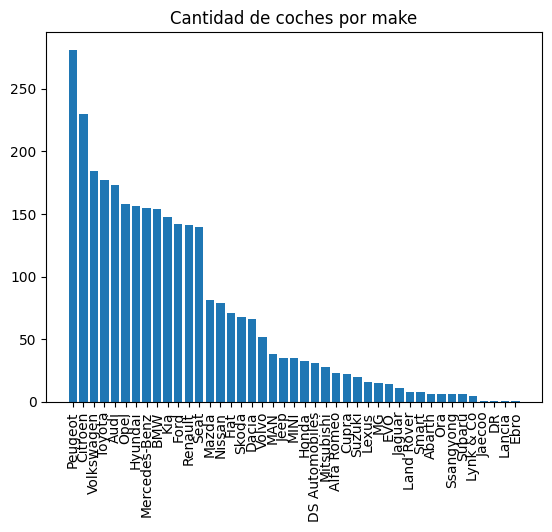

In [574]:
plt.bar(data['make'].value_counts().index, data['make'].value_counts().values)
plt.xticks(rotation=90)
plt.title('Cantidad de coches por make')
plt.show()

In [575]:
print(data['make'].value_counts())

make
Peugeot           281
Citroen           230
Volkswagen        184
Toyota            177
Audi              173
Opel              158
Hyundai           156
Mercedes-Benz     155
BMW               154
Kia               148
Ford              142
Renault           141
Seat              140
Mazda              81
Nissan             79
Fiat               71
Skoda              68
Dacia              66
Volvo              52
MAN                38
Jeep               35
MINI               35
Honda              33
DS Automobiles     31
Mitsubishi         28
Alfa Romeo         23
Cupra              22
Suzuki             20
Lexus              16
MG                 15
EVO                14
Jaguar             11
Land Rover          8
Smart               8
Abarth              6
Ora                 6
Ssangyong           6
Subaru              6
Lynk & Co           5
Jaecoo              1
DR                  1
Lancia              1
Ebro                1
Name: count, dtype: int64


In [576]:
df_makes_precio_medio = data.groupby(['make'])['price'].mean().reset_index()
df_makes_precio_medio

,make,price
0,Abarth,17932.333333
1,Alfa Romeo,20799.000000
2,Audi,21215.763006
3,BMW,22323.675325
4,Citroen,11541.173913
5,Cupra,27499.000000
6,DR,23899.000000
7,DS Automobiles,17157.064516
8,Dacia,13230.818182
9,EVO,20034.714286


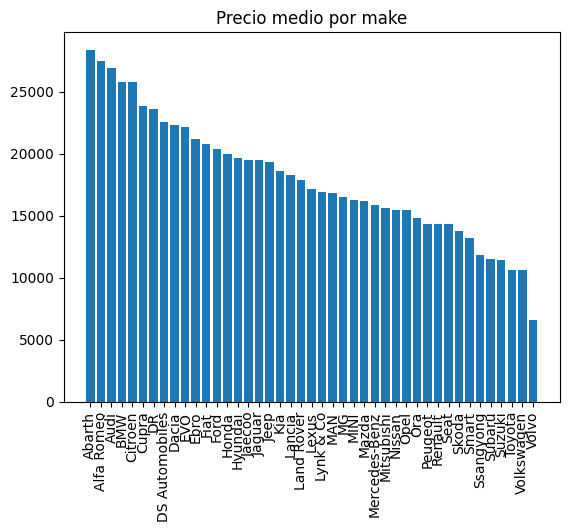

In [577]:
plt.bar(df_makes_precio_medio['make'], df_makes_precio_medio['price'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Precio medio por make')
plt.show()

In [578]:
df_makes_kms_medios = data.groupby(['make'])['kms'].mean().reset_index()

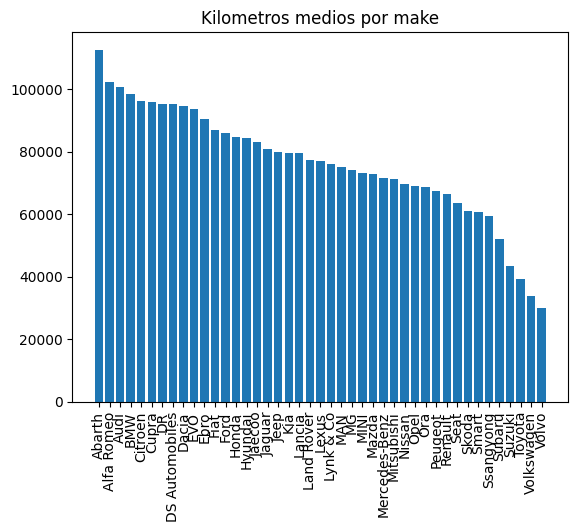

In [579]:
plt.bar(df_makes_kms_medios['make'], df_makes_kms_medios['kms'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Kilometros medios por make')
plt.show()

In [580]:
data[data['make'] == 'Abarth']

,make,registration,kms,gear_type,fuel_type,power,price,version,model
20,Abarth,03/2018,38445,Manual,Gasolina,145,15999,1.4 Turbo,500
1422,Abarth,09/2020,90134,Manual,Gasolina,145,14699,1.4 Turbo,595
2501,Abarth,11/2022,31198,Manual,Gasolina,179,21599,1.4 Turbo,695
2609,Abarth,08/2024,22446,Manual,Gasolina,179,24899,1.4 Turbo,500
2675,Abarth,05/2019,100392,Automático,Gasolina,180,15499,1.4,595c
2740,Abarth,05/2019,82228,Manual,Gasolina,160,14899,1.4,595


In [581]:
data['registration'] = pd.to_datetime(data['registration'], format='%m/%Y')
data.info()

<class 'pandas.DataFrame'>
Index: 3026 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   make          3026 non-null   str           
 1   registration  3026 non-null   datetime64[us]
 2   kms           3026 non-null   int64         
 3   gear_type     3026 non-null   str           
 4   fuel_type     3026 non-null   str           
 5   power         3026 non-null   int64         
 6   price         3026 non-null   int64         
 7   version       3026 non-null   str           
 8   model         3026 non-null   str           
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 236.4 KB


In [582]:
df_groupby_model = data.groupby(['model', 'make']).agg({
    'kms': 'mean', 
    'power': 'mean', 
    'registration': 'mean', 
    'price': 'mean'
}).reset_index()
df_groupby_model

,model,make,kms,power,registration,price
0,01,Lynk & Co,68843.000000,261.000000,2022-12-12 19:12:00.000000,22139.000000
1,108,Peugeot,53475.571429,71.714286,2019-04-05 17:08:34.285714,9056.142857
2,2,Mazda,60646.400000,92.200000,2019-12-31 04:48:00.000000,13999.000000
3,2008,Peugeot,70269.750000,114.616667,2019-09-12 11:36:00.000000,12780.666667
4,208,Peugeot,72206.042553,93.702128,2019-07-03 08:40:51.063829,10116.021277
...,...,...,...,...,...,...
305,Yaris cross,Toyota,34812.777778,119.000000,2023-05-05 10:40:00.000000,24421.222222
306,Ypsilon,Lancia,96332.000000,70.000000,2014-06-01 00:00:00.000000,6599.000000
307,Zafira tourer,Opel,98187.222222,131.777778,2016-04-21 13:20:00.000000,11243.444444
308,Zr-v,Honda,26135.500000,184.000000,2024-05-01 12:00:00.000000,33199.000000


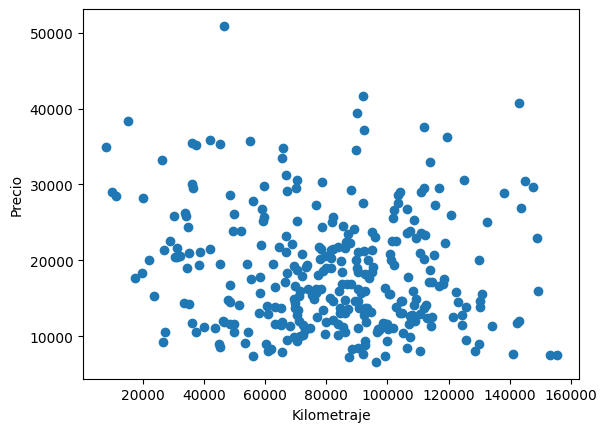

In [583]:
plt.scatter(x=df_groupby_model['kms'], y=df_groupby_model['price'])
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

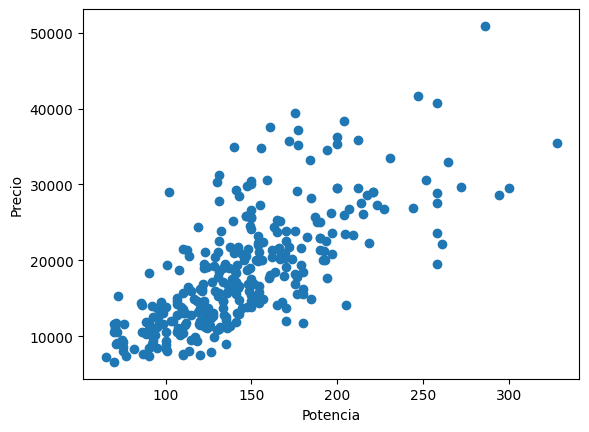

In [584]:
plt.scatter(x=df_groupby_model['power'], y=df_groupby_model['price'])
plt.xlabel('Potencia')
plt.ylabel('Precio')
plt.show()

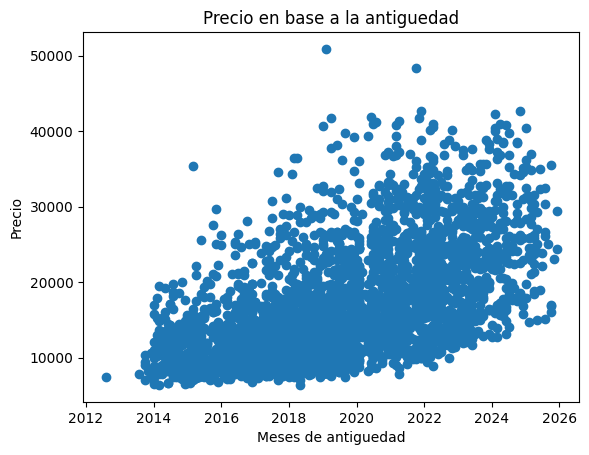

In [585]:
plt.scatter(x=data['registration'], y=data['price'])
plt.title('Precio en base a la antiguedad')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Precio')
plt.show()

In [586]:
# Transformamos las columnas categoricas
data['model_unique'] = data['make'] + "_" + data['model']
data['version_unique'] = data['model_unique'] + "_" + data['version']

le = LabelEncoder()
data['make_num'] = le.fit_transform(data['make'])
data['model_num'] = le.fit_transform(data['model_unique'])
data['version_num'] = le.fit_transform(data['version_unique'])

oe = OneHotEncoder()
cols_to_encode = ['gear_type', 'fuel_type']

encoded_array = oe.fit_transform(data[cols_to_encode]).toarray() 

df_encoded = pd.DataFrame(
    encoded_array, 
    columns=oe.get_feature_names_out(cols_to_encode),
    index=data.index
)

df_final = pd.concat([data, df_encoded], axis=1)

cols_to_drop = [
    'make', 'model', 'version', 'fuel_type', 'gear_type', 
    'model_unique', 'version_unique'
]

hoy = pd.Timestamp.now()
df_final['antiguedad_meses'] = ((hoy.year - data['registration'].dt.year) * 12 + (hoy.month - data['registration'].dt.month))

# Eliminamos la columna original de fecha porque el modelo no la entiende
df_final = df_final.drop(columns=['registration'])

df_final.drop(cols_to_drop, axis=1, inplace=True)

In [587]:
df_final.head()

,kms,power,price,make_num,model_num,version_num,gear_type_Automático,gear_type_Doble embrague,gear_type_Manual,gear_type_Semi-automático,fuel_type_Diésel,fuel_type_Gasolina,fuel_type_Híbrido,antiguedad_meses
0,17222,128,12599,18,130,403,0.0,0.0,1.0,0.0,1.0,0.0,0.0,142
1,32462,265,40999,18,136,417,1.0,0.0,0.0,0.0,0.0,0.0,1.0,24
2,78068,150,17299,32,207,662,0.0,0.0,1.0,0.0,1.0,0.0,0.0,93
3,19060,218,39999,27,170,541,1.0,0.0,0.0,0.0,0.0,0.0,1.0,26
4,94982,100,9399,4,46,169,0.0,0.0,1.0,0.0,1.0,0.0,0.0,114


Text(0.5, 1.0, 'Outliers de Kilómetros')

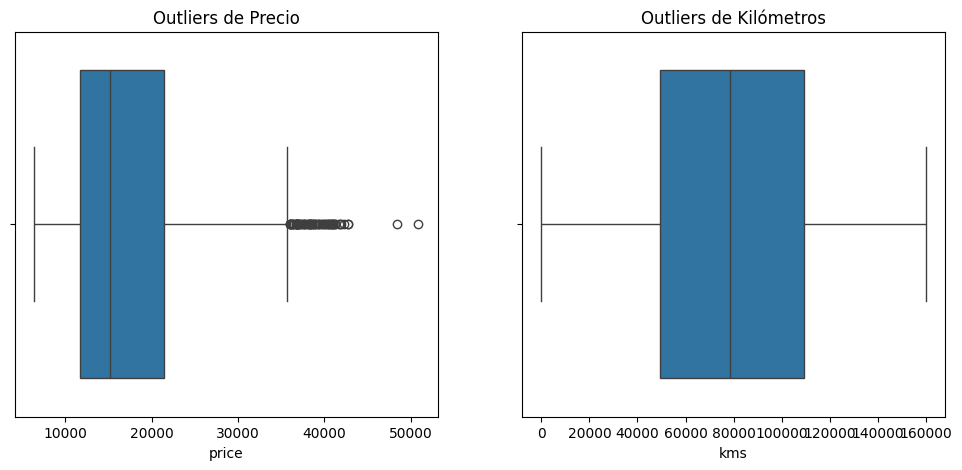

In [588]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=data['price'])
plt.title('Outliers de Precio')

# Gráfico para kms
plt.subplot(1, 2, 2)
sns.boxplot(x=data['kms'])
plt.title('Outliers de Kilómetros')

In [589]:
#  Vemos el porcentaje de outliers
print(df_final[df_final['price'] > 35000]['price'].count())
total_outliers = len(df_final[df_final['price'] > 34000])
porcentaje = (total_outliers / len(df_final)) * 100
print(f"Porcentaje de outliers en price: {porcentaje}")

77
Porcentaje de outliers en price: 3.1725049570389956


In [590]:
df_final = df_final[df_final['price'] <= 32500]

Text(0.5, 1.0, 'Outliers de Precio')

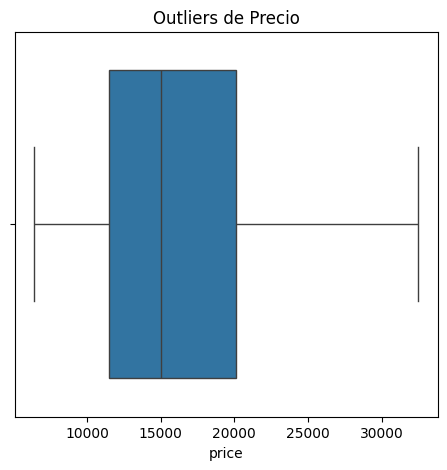

In [591]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=df_final['price'])
plt.title('Outliers de Precio')

In [592]:
# Exportamos el dataset
df_clean = data[data['price'] <= 32500].drop(columns=['model_unique', 'version_unique', 'make_num', 'model_num', 'version_num'])

In [593]:
# División de datos
X = df_final.drop(columns='price')
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [594]:
X.info()

<class 'pandas.DataFrame'>
Index: 2902 entries, 0 to 3113
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   kms                        2902 non-null   int64  
 1   power                      2902 non-null   int64  
 2   make_num                   2902 non-null   int64  
 3   model_num                  2902 non-null   int64  
 4   version_num                2902 non-null   int64  
 5   gear_type_Automático       2902 non-null   float64
 6   gear_type_Doble embrague   2902 non-null   float64
 7   gear_type_Manual           2902 non-null   float64
 8   gear_type_Semi-automático  2902 non-null   float64
 9   fuel_type_Diésel           2902 non-null   float64
 10  fuel_type_Gasolina         2902 non-null   float64
 11  fuel_type_Híbrido          2902 non-null   float64
 12  antiguedad_meses           2902 non-null   int32  
dtypes: float64(7), int32(1), int64(5)
memory usage: 306.1 KB


In [595]:
# Entrenamiento del modelo
# Como es calcular un precio, usaremos una regresión
model = XGBRegressor(n_estimators=450, learning_rate=0.07, max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [596]:
# Para calcular el MAE real, revertimos con expm1 de numpy
preds_log = model.predict(X_test)

mae = mean_absolute_error(y_test, preds_log)
r2 = r2_score(y_test, preds_log)

print(f"MAE: {mae}")
print(f"R2: {r2}")

MAE: 1354.07568359375
R2: 0.9007650017738342


In [597]:
# Calcular el error relativo
error_relativo = (mae / df_final['price'].mean()) * 100

print(f"Error relativo: {error_relativo}")

Error relativo: 8.294167633392606


In [598]:
# Guardar modelo
if not os.path.exists('../ai_models'):
    os.makedirs('../ai_models')

if not os.path.exists('../ai_models/compra_coches'):
    os.makedirs('../ai_models/compra_coches')

# Guardar modelo
joblib.dump(model, '../ai_models/compra_coches/modelo_compra_coches_iberia.pkl')

# Guardr lista de columnas de los datos a entrenar
joblib.dump(X_train.columns, '../ai_models/compra_coches/columnas_modelo_compra_coches_iberia.pkl')

['../ai_models/compra_coches/columnas_modelo_compra_coches_iberia.pkl']

In [599]:
def predecir_coche(power, make_num, model_num, version_num, kms, meses, gear, fuel):
    # Creamos la fila base con ceros
    nuevo_coche = pd.DataFrame(0, index=[0], columns=X_train.columns)
    
    # Rellenamos valores numéricos y ordinales
    nuevo_coche['kms'] = kms
    nuevo_coche['antiguedad_meses'] = meses
    nuevo_coche['power'] = power
    nuevo_coche['make_num'] = make_num
    nuevo_coche['model_num'] = model_num
    nuevo_coche['version_num'] = version_num
    
    # Activamos el Dummy correspondiente basándonos en el texto
    # Ejemplo: si gear='Manual', activa 'gear_type_Manual'
    col_gear = f'gear_type_{gear}'
    col_fuel = f'fuel_type_{fuel}'
    
    if col_gear in nuevo_coche.columns:
        nuevo_coche[col_gear] = 1.0
    if col_fuel in nuevo_coche.columns:
        nuevo_coche[col_fuel] = 1.0
    
    prediccion = model.predict(nuevo_coche)
    
    return prediccion[0]


In [600]:
# Ejemplo de uso mucho más natural:
precio_estimado = predecir_coche(90, 5, 12, 104, 14469, 48, 'Manual', 'Diésel')
print(f"El valor estimado para este coche es de: {precio_estimado:.2f} €")

El valor estimado para este coche es de: 18416.64 €


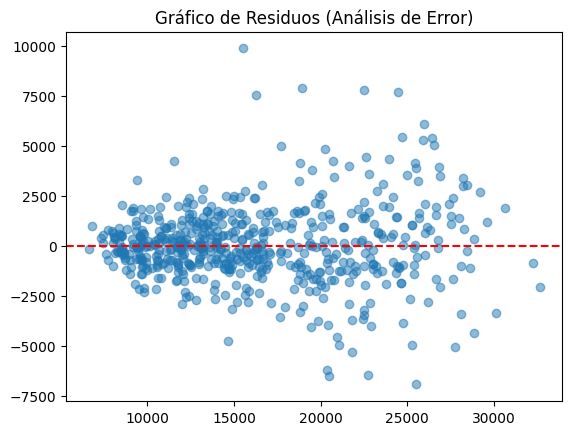

In [601]:
error = y_test - model.predict(X_test)
plt.scatter(model.predict(X_test), error, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Gráfico de Residuos (Análisis de Error)')
plt.show()

In [602]:
df_clean['is_prediction'] = False
df_clean['rep_id'] = 1

df_clean.to_csv('../datasets/coches_clean.csv', index=False)

In [603]:
fuel_bbdd = {
    'id': range(1, len(df_clean['fuel_type'].unique()) + 1),
    'nombre': sorted(df_clean['fuel_type'].unique())
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_fuel_types.csv', index=False)

In [604]:
fuel_bbdd = {
    'id': range(1, len(df_clean['gear_type'].unique()) + 1),
    'nombre': sorted(df_clean['gear_type'].unique())
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_gear_types.csv', index=False)

In [605]:
df_marcas = df_marcas.rename(columns={
    'marca_id': 'id',
    'nombre_marca': 'nombre'
})

df_modelos = df_modelos.rename(columns={
    'modelo_id': 'id',
    'nombre_modelo': 'nombre',
    'marca_id': 'id_marca',
})

df_modelos = df_modelos.drop('id_web', axis=1)

df_versiones = df_versiones.rename(columns={
    'version_id': 'id',
    'clave_motor': 'nombre',
    'modelo_id': 'id_modelo',
})

df_versiones = df_versiones.drop('nombre_completo', axis=1)

df_versiones.to_csv('../datasets/seed_versiones_bbdd.csv', index=False)
df_modelos.to_csv('../datasets/seed_modelos_bbdd.csv', index=False)
df_marcas.to_csv('../datasets/seed_marcas_bbdd.csv', index=False)
